In [14]:
#Task 1: Measure latency vs batch size

import torch
import transformers
import time
import os

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)

PyTorch version: 2.11.0+cpu
Transformers version: 5.16.1


In [15]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

model.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [3]:
texts = [
    "Ryan Gosling was absolutely brilliant in this movie.",
    "Christopher Nolan knows how to make a story feel massive.",
    "Margot Robbie completely owned every scene she was in.",
    "I still think Leonardo DiCaprio deserved more recognition for this role.",
    "The cinematography made the movie look ridiculously beautiful.",
    "Cillian Murphy gave the kind of performance that stays in your head.",
    "The ending was unexpected, but somehow it made the whole movie better.",
    "I would happily watch this movie again just for the performances."
]

inputs = tokenizer(texts, padding = True, truncation = True, return_tensors = "pt")
print(inputs)

{'input_ids': tensor([[  101,  4575,  2175, 28886,  2001,  7078,  8235,  1999,  2023,  3185,
          1012,   102,     0,     0,     0,     0,     0],
        [  101,  5696, 13401,  4282,  2129,  2000,  2191,  1037,  2466,  2514,
          5294,  1012,   102,     0,     0,     0,     0],
        [  101, 29210, 12289,  3294,  3079,  2296,  3496,  2016,  2001,  1999,
          1012,   102,     0,     0,     0,     0,     0],
        [  101,  1045,  2145,  2228, 14720,  4487, 17695,  9488, 10849,  2062,
          5038,  2005,  2023,  2535,  1012,   102,     0],
        [  101,  1996, 16434,  2081,  1996,  3185,  2298,  9951,  2135,  3376,
          1012,   102,     0,     0,     0,     0,     0],
        [  101, 25022,  6894,  2319,  7104,  2435,  1996,  2785,  1997,  2836,
          2008, 12237,  1999,  2115,  2132,  1012,   102],
        [  101,  1996,  4566,  2001,  9223,  1010,  2021,  5064,  2009,  2081,
          1996,  2878,  3185,  2488,  1012,   102,     0],
        [  101,  104

In [4]:
with torch.no_grad():
  model(**inputs)

In [5]:
batch_sizes = [1,2,4,6,8]
total_times = []
time_per_sample = []

for batch_size in batch_sizes:
  batch_inputs = {
      key: value[:batch_size]
      for key, value in inputs.items()
  }

  start_time = time.time()
  with torch.no_grad():
    model(**batch_inputs)
  end_time = time.time()

  total_time = end_time - start_time
  per_sample = total_time / batch_size

  total_times.append(total_time)
  time_per_sample.append(per_sample)

  print(f"Batch size: {batch_size}")
  print(f"Total time: {total_time:.4f} seconds")
  print(f"Time per sample: {per_sample:.4f} seconds")
  print()


Batch size: 1
Total time: 0.0956 seconds
Time per sample: 0.0956 seconds

Batch size: 2
Total time: 0.1167 seconds
Time per sample: 0.0583 seconds

Batch size: 4
Total time: 0.1931 seconds
Time per sample: 0.0483 seconds

Batch size: 6
Total time: 0.2970 seconds
Time per sample: 0.0495 seconds

Batch size: 8
Total time: 0.3874 seconds
Time per sample: 0.0484 seconds



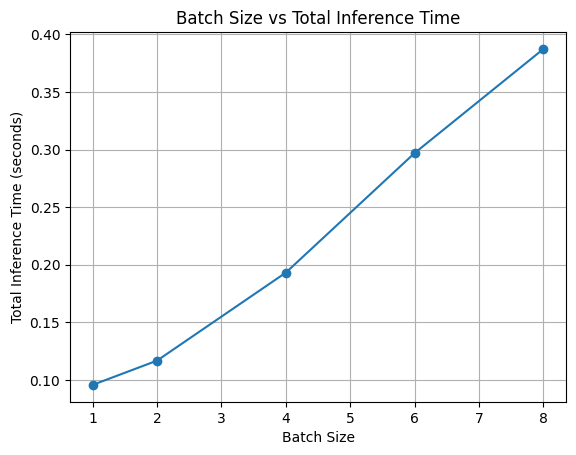

In [6]:
import matplotlib.pyplot as plt

plt.plot(batch_sizes, total_times, marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Total Inference Time (seconds)")
plt.title("Batch Size vs Total Inference Time")
plt.grid()
plt.show()

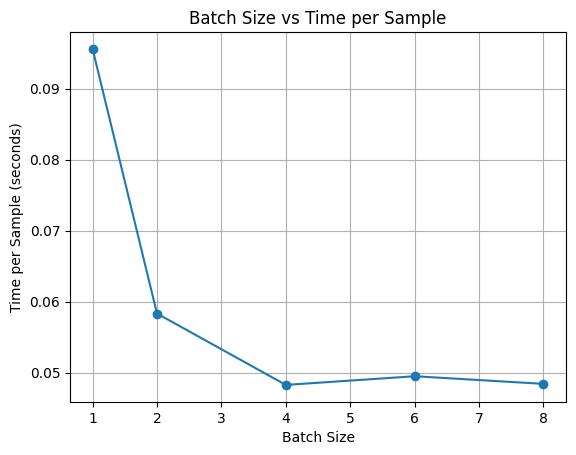

In [7]:
plt.plot(batch_sizes, time_per_sample, marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Time per Sample (seconds)")
plt.title("Batch Size vs Time per Sample")
plt.grid()
plt.show()

So i observed that the total time increased as the batch size became larger, since more inputs were processed at once.However, the time taken for each sample decreased, especially when moving from batch size 1 to larger batches.This shows that batching makes the inference process more efficient.

In [10]:

#Task 2: Implement basic quantization

quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype = torch.qint8
)

/tmp/ipykernel_599/3012883917.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [9]:
quantized_model.eval()

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
          (k_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
          (v_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
          (out_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_l

In [12]:
torch.save(model.state_dict(), "original.pth")
torch.save(quantized_model.state_dict(), "quantized.pth")

original_size = os.path.getsize("original.pth")
quantized_size = os.path.getsize("quantized.pth")

print(f"Original model size: {original_size / (1024 * 1024):.2f} MB")
print(f"Quantized model size: {quantized_size / (1024 * 1024):.2f} MB")



Original model size: 253.19 MB
Quantized model size: 131.72 MB


In [13]:
def measure_inference(model, inputs, runs = 7):
  with torch.no_grad():
    model(**inputs)

  start_time = time.time()

  for i in range(runs):
    with torch.no_grad():
      model(**inputs)

  end_time = time.time()

  average_time = (end_time - start_time)/ runs

  return average_time


original_time = measure_inference(model, inputs)
quantized_time = measure_inference(quantized_model, inputs)

print(f"Original model inference time: {original_time:.4f} seconds")
print(f"Quantized model inference time: {quantized_time:.4f} seconds")

Original model inference time: 0.3203 seconds
Quantized model inference time: 0.1490 seconds


After quantization, the model size decreased from 253.19 MB to 131.72 MB.The inference time also dropped from 0.3203 seconds to 0.1490 seconds, so the quantized model was noticeably faster.Overall, quantization helped reduce both the model size and inference time.